In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import geopandas as gpd
import xarray as xr

from glob import glob
from tqdm import tqdm
from pathlib import Path
from datetime import timedelta
from shapely import wkt
from shapely.geometry import Point, LineString

save_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph_manual")
metadata_dir = save_dir / "metadata"

sites_dir = save_dir / "basin_lists"
sites_dir.mkdir(parents=True, exist_ok=True)

fig_dir = save_dir / '_figures' / 'train_test'
fig_dir.mkdir(parents=True, exist_ok=True)

gauges = gpd.read_parquet(metadata_dir / "gauges.parquet").set_index('site_id')

subs_df = pd.read_parquet(metadata_dir / 'subbasins.parquet', columns=['site_id', 'is_gauge', 'uparea_km2', 'outlet_id'])
subs_df.index = subs_df.index.astype(str)

In [2]:
matches = gauges.join(subs_df, how='inner')
matches

,name,area,active,latitude,longitude,last_updated,min_date,max_date,min_discharge,max_discharge,...,count_discharge,provider_misc,geometry,provider,COMID,position,terminal_site_id,is_gauge,uparea_km2,outlet_id
site_id,,,,,,,,,,,,,,,,,,,,,
EAUF-10250001,La Grande Rivière à Goyaves à Sainte-Rose [La ...,NaN,True,16.279712,-61.668130,2025-09-09,1973-03-21,2025-08-31,0.7400,280.088,...,4686.0,None,POINT (-61.66796 16.27954),eauf,76004387,0.390817,EAUF-10250001,True,130.266710,EAUF-10250001
EAUF-12120001,La rivière des Pères à Baillif,NaN,True,16.010760,-61.739270,2025-09-09,1983-04-29,2025-09-01,0.0380,37.724,...,7643.0,None,POINT (-61.73927 16.01),eauf,76004383,0.462555,EAUF-12120001,True,26.258193,EAUF-12120001
EAUF-12210001,La Grande Rivière de Vieux-Habitants à Vieux-H...,NaN,True,16.086609,-61.725164,2025-09-09,1980-04-15,2025-08-31,0.3580,72.013,...,10907.0,None,POINT (-61.73286 16.06881),eauf,76004385,0.990000,EAUF-12210001,True,19.611900,EAUF-12210001
EAUF-22050001,La rivière du Lorrain au Lorrain [SCNA],NaN,True,14.788162,-61.055505,2025-09-09,2011-02-09,2025-09-08,0.2980,34.989,...,5061.0,None,POINT (-61.05534 14.788),eauf,61000007,0.871666,EAUF-22050001,True,26.704660,EAUF-22050001
EAUF-22250001,La rivière du Galion à la Trinité [Grand Galion],NaN,True,14.717008,-60.960337,2025-09-09,2011-12-02,2025-09-08,0.0520,65.140,...,4542.0,None,POINT (-60.96 14.71667),eauf,61000006,0.899394,EAUF-22250001,True,35.480585,EAUF-22250001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BRANA-88260000,PASSO DAS PEDRAS,6920.0,False,-32.519400,-53.455800,2025-11-06,2015-01-01,2025-08-31,1.5080,2789.540,...,3799.0,None,POINT (-53.45833 -32.5194),brana,64072596,0.329889,BRANA-88260000,True,6925.425331,BRANA-88260000
BRANA-88575000,CERRO CHATO,1050.0,False,-31.864700,-53.268300,2025-11-06,1976-08-01,2025-06-30,0.3332,944.923,...,16830.0,None,POINT (-53.26817 -31.86483),brana,64068088,0.021428,BRANA-88641000,True,1054.608096,BRANA-88641000
BRANA-88641000,PEDRO OSÓRIO,4700.0,False,-31.863300,-52.816100,2025-11-06,2000-04-19,2025-08-31,0.4346,7479.060,...,9112.0,None,POINT (-52.81583 -31.86083),brana,64067719,0.289136,BRANA-88641000,True,4714.329407,BRANA-88641000


In [3]:
matches[matches['outlet_id']=='USGS-07374000']

,name,area,active,latitude,longitude,last_updated,min_date,max_date,min_discharge,max_discharge,...,count_discharge,provider_misc,geometry,provider,COMID,position,terminal_site_id,is_gauge,uparea_km2,outlet_id
site_id,,,,,,,,,,,,,,,,,,,,,
ECCC-11AA001,NORTH MILK RIVER NEAR INTERNATIONAL BOUNDARY,239.000000,True,49.021961,-112.972931,2025-11-07,1950-03-01,2025-11-01,0.088000,61.500000,...,18903.0,None,POINT (-112.97257 49.0216),eccc,74000070,0.085743,USGS-07374000,True,258.153924,USGS-07374000
ECCC-11AA005,MILK RIVER AT MILK RIVER,2720.000000,True,49.143600,-112.081703,2025-11-07,1950-01-01,2025-11-07,0.001389,222.000000,...,27689.0,None,POINT (-112.08197 49.14387),eccc,74000038,0.750409,USGS-07374000,True,2733.899453,USGS-07374000
ECCC-11AA025,MILK RIVER AT WESTERN CROSSING OF INTERNATIONA...,1050.000000,True,49.007530,-112.545891,2025-11-07,1950-03-01,2025-08-16,0.000008,153.000000,...,17213.0,None,POINT (-112.54583 49.00753),eccc,74000071,0.688342,USGS-07374000,True,1040.129468,USGS-07374000
USGS-03007800,"Allegheny River at Port Allegany, PA",642.313858,True,41.818676,-78.292791,2025-09-09,1974-10-01,2025-09-08,0.112135,263.913010,...,18604.0,None,POINT (-78.29282 41.81865),usgs,74024147,0.189307,USGS-07374000,True,652.459505,USGS-07374000
USGS-03010500,"Allegheny River at Eldred, PA",1424.486380,True,41.963398,-78.386129,2025-09-09,1950-01-01,2025-09-08,0.453070,1577.248355,...,27644.0,None,POINT (-78.38637 41.96363),usgs,74023951,0.989664,USGS-07374000,True,1422.564575,USGS-07374000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-07263115,"Fourche La Fave River near Houston, AR",2740.193799,True,35.012032,-92.723498,2025-09-09,2023-01-06,2025-09-08,0.000850,348.297213,...,708.0,None,POINT (-92.72365 35.01218),usgs,74061870,0.397824,USGS-07374000,True,2744.679201,USGS-07374000
USGS-07263295,"Maumelle River at Williams Junction, AR",119.397858,True,34.876111,-92.774444,2025-09-09,1989-08-10,2025-09-02,0.000283,188.307030,...,11424.0,None,POINT (-92.77444 34.87583),usgs,74063286,0.045926,USGS-07374000,True,119.139902,USGS-07374000
USGS-07263296,"Maumelle River near Wye, AR",189.068192,True,34.878889,-92.685556,2025-09-09,2007-07-11,2025-09-08,0.000283,267.594200,...,5807.0,None,POINT (-92.68556 34.87889),usgs,74063286,0.333542,USGS-07374000,True,189.797383,USGS-07374000


In [67]:
from sklearn.model_selection import train_test_split


train_dfs = []
test_dfs = []

for basin_id, grp in tqdm(matches.groupby('outlet_id')):
    if len(grp) > 4:
        train, test = train_test_split(
            grp,
            test_size=0.3,
            random_state=42,
            shuffle=True,
        )
        train_dfs.append(train)
        test_dfs.append(test)
    else:
        train_dfs.append(grp)

train = pd.concat(train_dfs)
test = pd.concat(test_dfs)


train

100%|██████████| 1472/1472 [00:01<00:00, 1449.01it/s]


,name,area,active,latitude,longitude,last_updated,min_date,max_date,min_discharge,max_discharge,...,count_discharge,provider_misc,geometry,provider,COMID,position,terminal_site_id,is_gauge,uparea_km2,outlet_id
site_id,,,,,,,,,,,,,,,,,,,,,
ABOM-100288010,Murray River - Pinjarra,NaN,False,-32.633517,115.878081,2025-09-09,1991-10-24,2025-09-07,0.019000,289.706000,...,12049.0,None,POINT (115.8783 -32.6333),abom,56139495,0.225941,ABOM-100288010,True,7075.644195,ABOM-100288010
ABOM-102903010,Williams River - Saddleback Rd Bridge,NaN,False,-32.994466,116.428563,2025-09-09,1966-06-19,2025-09-07,0.001000,227.972000,...,21376.0,None,POINT (116.42856 -32.99417),abom,56139789,0.717371,ABOM-100288010,True,1412.463439,ABOM-100288010
ABOM-97444010,Murray River - Baden Powell,NaN,False,-32.772164,116.084317,2025-09-09,1952-03-31,2025-09-07,0.001000,519.575000,...,23922.0,None,POINT (116.08441 -32.77226),abom,56139504,0.046685,ABOM-100288010,True,6776.948169,ABOM-100288010
ABOM-102984010,Hotham River - Marradong Rd Bridge,NaN,False,-32.865404,116.397904,2025-09-09,1966-06-16,2025-09-07,0.001000,244.823000,...,21077.0,None,POINT (116.39792 -32.86542),abom,56141130,0.625351,ABOM-100288010,True,3977.514757,ABOM-100288010
ABOM-10046010,Howard River - Koolpinya Stockyard Iron Bridge,NaN,False,-12.462515,131.083858,2025-09-09,1963-10-31,2025-09-07,0.001000,238.441000,...,14352.0,None,POINT (131.08386 -12.4625),abom,56001483,0.749447,ABOM-10046010,True,159.253650,ABOM-10046010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-50129254,"RIO LOCO AT LAS LATAS NR LA JOYA NR GUANICA, PR",NaN,True,18.007182,-66.876320,2025-09-09,2006-12-21,2025-09-08,0.000283,58.899041,...,4976.0,None,POINT (-66.87667 18.00718),usgs,76004273,0.453851,USGS-50129254,True,42.674493,USGS-50129254
USGS-50136400,"RIO ROSARIO NR HORMIGUEROS, PR",47.396547,True,18.158099,-67.085388,2025-09-09,1985-10-01,2025-09-08,0.062297,125.160462,...,14580.0,None,POINT (-67.08531 18.15802),usgs,76003816,0.443336,USGS-50138000,True,51.402873,USGS-50138000
USGS-50138000,"RIO GUANAJIBO NR HORMIGUEROS, PR",310.797028,True,18.140694,-67.148374,2025-09-09,1973-01-01,2025-09-08,0.141584,1764.139543,...,19242.0,None,POINT (-67.14837 18.14083),usgs,76003550,0.726832,USGS-50138000,True,312.856752,USGS-50138000


In [69]:
def write_basin_subbasin(df, file):
    tmp = df.reset_index()[['outlet_id','site_id']]
    tmp = tmp.rename(columns={'outlet_id':'basin', 'site_id':'subbasin'})
    tmp.to_csv(file, index=False)

write_basin_subbasin(train, sites_dir / 'train_8020.csv')
write_basin_subbasin(test, sites_dir / 'test_8020.csv')

In [70]:
print(len(train))
print(len(test))

8806
3238


In [90]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

def plot_train_test(_train, _test):
    _train['subset'] = 'train'
    _test['subset'] = 'test'
    all_basin = pd.concat([_train, _test])

    colors = ['tab:blue', 'tab:orange']
    cmap = ListedColormap(colors)

    
    plt.close('all')
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    all_basin.plot('subset', markersize=0.2, categories=['train','test'], legend=True, ax=axes[0], cmap=cmap)
    # Move legend to top left
    legend = axes[0].get_legend()
    legend.set_bbox_to_anchor((1, 1)) 

    bin_range = (
        np.floor(np.log10(all_basin['uparea_km2'].min())),
        np.ceil(np.log10(all_basin['uparea_km2'].max()))
    )
    # bmax = np.ceil(np.log10(train_df['hybas_area'].max()))
    # bmax = np.ceil(np.log10(train_df['hybas_area'].max()))
    
    axes[1].hist(np.log10(_train['uparea_km2']), bins=10, range=bin_range)
    axes[1].hist(np.log10(_test['uparea_km2']), alpha=0.7, bins=10, range=bin_range)
    axes[1].set_xlabel('Log10 Upstream Area (km)')

    fig.tight_layout()
    
    
    return fig, axes

In [54]:
train

,is_gauge,uparea_km2,outlet_id,name,area,active,latitude,longitude,last_updated,min_date,...,max_discharge,mean_discharge,count_discharge,provider_misc,geometry,provider,COMID,position,terminal_site_id,subset
site_id,,,,,,,,,,,,,,,,,,,,,
ABOM-100288010,True,7075.644195,ABOM-100288010,Murray River - Pinjarra,NaN,False,-32.633517,115.878081,2025-09-09,1991-10-24,...,289.706000,7.570296,12049.0,None,POINT (115.8783 -32.6333),abom,56139495,0.225941,ABOM-100288010,train
ABOM-97444010,True,6776.948169,ABOM-100288010,Murray River - Baden Powell,NaN,False,-32.772164,116.084317,2025-09-09,1952-03-31,...,519.575000,8.810467,23922.0,None,POINT (116.08441 -32.77226),abom,56139504,0.046685,ABOM-100288010,train
ABOM-102903010,True,1412.463439,ABOM-100288010,Williams River - Saddleback Rd Bridge,NaN,False,-32.994466,116.428563,2025-09-09,1966-06-19,...,227.972000,1.997985,21376.0,None,POINT (116.42856 -32.99417),abom,56139789,0.717371,ABOM-100288010,train
ABOM-102984010,True,3977.514757,ABOM-100288010,Hotham River - Marradong Rd Bridge,NaN,False,-32.865404,116.397904,2025-09-09,1966-06-16,...,244.823000,3.222303,21077.0,None,POINT (116.39792 -32.86542),abom,56141130,0.625351,ABOM-100288010,train
ABOM-10046010,True,159.253650,ABOM-10046010,Howard River - Koolpinya Stockyard Iron Bridge,NaN,False,-12.462515,131.083858,2025-09-09,1963-10-31,...,238.441000,3.408128,14352.0,None,POINT (131.08386 -12.4625),abom,56001483,0.749447,ABOM-10046010,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-50129254,True,42.674493,USGS-50129254,"RIO LOCO AT LAS LATAS NR LA JOYA NR GUANICA, PR",NaN,True,18.007182,-66.876320,2025-09-09,2006-12-21,...,58.899041,1.836071,4976.0,None,POINT (-66.87667 18.00718),usgs,76004273,0.453851,USGS-50129254,train
USGS-50138000,True,312.856752,USGS-50138000,"RIO GUANAJIBO NR HORMIGUEROS, PR",310.797028,True,18.140694,-67.148374,2025-09-09,1973-01-01,...,1764.139543,5.713608,19242.0,None,POINT (-67.14837 18.14083),usgs,76003550,0.726832,USGS-50138000,train
USGS-50136400,True,51.402873,USGS-50138000,"RIO ROSARIO NR HORMIGUEROS, PR",47.396547,True,18.158099,-67.085388,2025-09-09,1985-10-01,...,125.160462,1.541356,14580.0,None,POINT (-67.08531 18.15802),usgs,76003816,0.443336,USGS-50138000,train


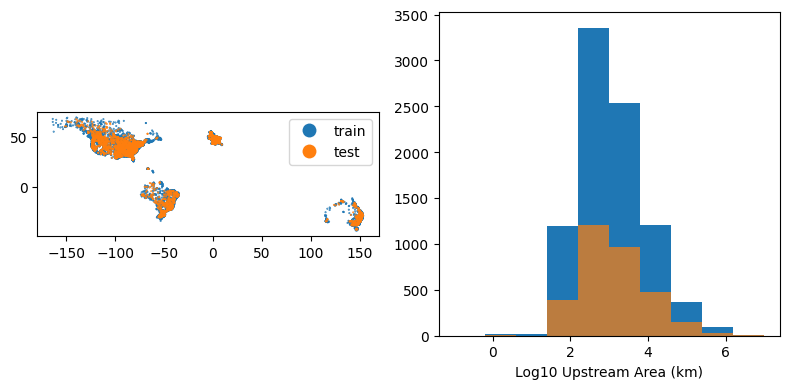

In [91]:
fig, axes = plot_train_test(train, test)
# fig.savefig(fig_dir / f'random_split_{basin}.png', dpi=300)

# write_index_sites(train_df, f'{basin}_random_train')
# write_index_sites(test_df, f'{basin}_random_test')

In [37]:
sword_sites

,outlet,total_area,unitarea,reservoir,custom,reach_id,sword_area,sword_distance,lake_reach_ids,lake_pld_ids,...,rdd_mk_sav,hft_ix_s93,hft_ix_s09,gad_id_smj,gdp_ud_sav,gdp_ud_ssu,hdi_ix_sav,hybas_area_diff,geometry,subset
comid,,,,,,,,,,,,,,,,,,,,,
USGS-03010820,POINT (-78.4508 42.0725),3023.0,761.0,False,True,7.426990e+10,3618.283133,0.0,[],[],...,614,142,162,240,63747,9.479501e+08,952,0.054291,"MULTIPOLYGON (((-78.48042 42.26458, -78.48792 ...",train
USGS-03011020,POINT (-78.715 42.1567),4163.5,425.1,False,True,7.426990e+10,4018.413586,0.0,[],[],...,870,301,321,240,63747,2.879590e+08,952,0.001560,"MULTIPOLYGON (((-78.70125 42.13292, -78.70208 ...",train
USGS-03012550,POINT (-79.0117 41.8425),5591.6,754.3,True,True,7.426990e+10,4926.857910,0.0,"[74269900463, 74269900363, 74269900373, 742699...",[7421097453],...,422,140,154,240,53263,4.273464e+08,943,0.019112,"MULTIPOLYGON (((-78.98542 41.81875, -78.98875 ...",train
USGS-03015310,POINT (-79.1492 41.8433),8334.2,0.3,False,True,7.426990e+10,8675.438017,0.0,[],[],...,510,242,266,240,53263,2.454829e+08,943,-0.023380,"MULTIPOLYGON (((-79.14708 41.84625, -79.14708 ...",train
USGS-03016000,POINT (-79.4058 41.5708),9714.7,439.3,False,True,7.426990e+10,9554.466292,0.0,[],[],...,194,81,84,240,53263,7.743318e+07,943,-0.013482,"MULTIPOLYGON (((-79.39708 41.57208, -79.39708 ...",train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-03601600,POINT (-87.2658 35.72),4488.2,983.3,False,True,7.426220e+10,4155.014445,0.0,[],[],...,208,72,82,240,45808,5.052637e+07,810,0.001625,"MULTIPOLYGON (((-87.31792 35.66792, -87.31792 ...",train
USGS-03601990,POINT (-87.46 35.7842),5415.0,926.8,False,True,7.426220e+10,4583.058778,0.0,[],[],...,185,157,129,240,45808,2.195454e+08,810,-0.003237,"MULTIPOLYGON (((-87.47708 35.52208, -87.47958 ...",train
USGS-03603000,POINT (-87.7425 35.93),6784.7,372.2,False,True,7.426220e+10,5400.929199,0.0,[],[],...,172,55,56,240,45808,1.265268e+06,810,0.012538,"MULTIPOLYGON (((-87.74375 35.92292, -87.74375 ...",train


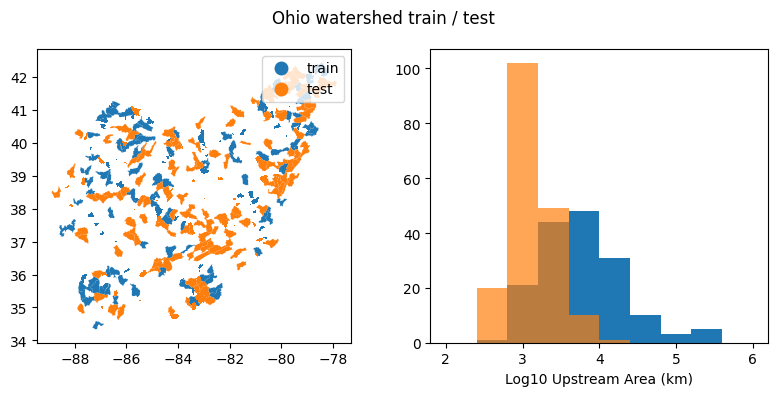

In [38]:
has_sword = ~all_sites['reach_id'].isna()
sword_sites = all_sites[has_sword].copy()
other_sites = all_sites[~has_sword].copy()

fig, axes = plot_train_test(sword_sites, other_sites)
fig.savefig(fig_dir / f'swot_split_{basin}.png', dpi=300)

write_index_sites(sword_sites, f'{basin}_Sword')
write_index_sites(other_sites, f'{basin}_noSword')